In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.utils.data
from torch.utils.data import DataLoader
from PIL import Image
from matplotlib import pyplot as plt
import seaborn as sns
import wandb
import math
import argparse
import datetime
import math
from time import time

In [2]:
import sys
from pathlib import Path

In [3]:
repo_root = Path.cwd()
ms_dir = repo_root / "multiscale diffusion"

if ms_dir.exists():
    sys.path.append(str(ms_dir))
elif (repo_root / "score_models.py").exists():
    sys.path.append(str(repo_root))



In [4]:
import score_models



In [5]:
from radial_band_utils import (
    generate_multiband_dataset_postmask,
    add_fourier_bias_to_result,
    make_radial_band_mask,
    radial_bandpass,
    make_radial_k_grid,
)



In [12]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"

components = [
    {"name": "coarse", "length_scale": 2.0,  "s": 2.0, "sigma_sq": 1.0, "band": (0.5, 4.0)},
    {"name": "mid1",   "length_scale": 6.0,  "s": 2.0, "sigma_sq": 1.0, "band": (4.0, 10.0)},
    {"name": "mid2",   "length_scale": 12.0, "s": 2.0, "sigma_sq": 1.0, "band": (10.0, 18.0)},
    {"name": "fine",   "length_scale": 24.0, "s": 2.0, "sigma_sq": 1.0, "band": (18.0, 32.0)},
]

result = generate_multiband_dataset_postmask(
    num_samples=200,
    grid_size=128,
    components=components,
    weights=[1.5, 1.0, 0.5, 0.15],
    seed=42,
    normalize=True,
)

result = add_fourier_bias_to_result(
    result,
    k0=26.0,
    width=2.0,
    strength=0.10,
    seed=123,
    overwrite_combined=False,
)

bands = result.get("bands", {c["name"]: c["band"] for c in components})
x_unbiased = result["combined"]
x_biased = result["combined_biased"]

analysis_source = "biased"  # set to "unbiased" to analyze clean training data
analysis_data = x_biased if analysis_source == "biased" else x_unbiased

B, N, _ = analysis_data.shape
print(f"device={device}, analysis_source={analysis_source}, samples={B}, grid={N}x{N}")



device=cpu, analysis_source=biased, samples=200, grid=128x128


In [13]:
n_train = 120
x_train_img = analysis_data[:n_train]      # (n_train, N, N)
x_holdout_img = analysis_data[n_train:]    # optional holdout

train_data = x_train_img.reshape(n_train, -1).contiguous().to(device)

diffusion_model = score_models.VP()
score_model = score_models.GMM_score(
    train_data,
    marginal_prob_mean=diffusion_model.marginal_prob_mean,
    marginal_prob_std=diffusion_model.marginal_prob_std,
).to(device)



In [14]:
n_samples = 32
latents = torch.randn(n_samples, train_data.shape[1], device=device)

samples = diffusion_model.SDEsampler(score_model, latents, num_steps=1000)
samples_img = samples.reshape(n_samples, 1, N, N)
x_gen = samples_img[:, 0]



In [17]:
FFT_NORM_RB = None  

RING_STEP_RB = 2.0  

@torch.no_grad()
def band_component_rb(x, band, norm=FFT_NORM_RB):
    """Return the spatial component of x restricted to a radial Fourier band."""
    if x.dim() == 2:
        x = x.unsqueeze(0)
    k_lo, k_hi = band
    m = make_radial_band_mask(x.shape[-1], k_lo, k_hi, device=x.device, dtype=x.dtype)
    return radial_bandpass(x, m, norm=norm)


@torch.no_grad()
def nn_by_coarse_rb(x_gen, x_train, coarse_band):
    """Nearest neighbor indices in training set based on the *coarse* band only."""
    cg = band_component_rb(x_gen, coarse_band).flatten(1)
    ct = band_component_rb(x_train, coarse_band).flatten(1)
    D = torch.cdist(cg, ct)
    idx = D.argmin(dim=1)
    return idx, D.min(dim=1).values


def make_ring_masks_rb(N, k_edges, device):
    """Stack of (K, N, N) binary masks for rings [k_edges[i], k_edges[i+1])."""
    kr = make_radial_k_grid(N, device=device)
    masks = []
    for lo, hi in zip(k_edges[:-1], k_edges[1:]):
        masks.append(((kr >= lo) & (kr < hi)).float())
    return torch.stack(masks, dim=0)


@torch.no_grad()
def ring_power_rb(x, ring_masks, fft_norm=FFT_NORM_RB):
    """Ring power spectrum (B, K)."""
    X = torch.fft.fft2(x, dim=(-2, -1), norm=fft_norm)
    rm = ring_masks.unsqueeze(0).to(X.device)  # (1,K,N,N)
    p = (X.abs() ** 2).unsqueeze(1) * rm
    return p.sum(dim=(-2, -1))  # (B, K)


@torch.no_grad()
def ring_rel_l2_sym_rb(xa, xb, ring_masks, fft_norm=FFT_NORM_RB, eps=1e-12):
    """
    Symmetric ring-wise relative L2:
      sqrt( ||Xa - Xb||^2 / (0.5*(||Xa||^2 + ||Xb||^2) + eps) )
    Returns (B, K).
    """
    Xa = torch.fft.fft2(xa, dim=(-2, -1), norm=fft_norm)
    Xb = torch.fft.fft2(xb, dim=(-2, -1), norm=fft_norm)
    D = Xa - Xb

    rm = ring_masks.unsqueeze(0).to(Xa.device)
    num = (D.abs() ** 2).unsqueeze(1) * rm
    den_a = (Xa.abs() ** 2).unsqueeze(1) * rm
    den_b = (Xb.abs() ** 2).unsqueeze(1) * rm

    num = num.sum(dim=(-2, -1))
    den = 0.5 * (den_a.sum(dim=(-2, -1)) + den_b.sum(dim=(-2, -1))) + eps
    return torch.sqrt(num / den)


@torch.no_grad()
def random_baseline_errors_rb(xg, xtr, ring_masks, n_ref=64, fft_norm=FFT_NORM_RB):
    """
    Returns baseline errors with random training references:
      (R, G, K)
    """
    errs = []
    for _ in range(n_ref):
        rand_idx = torch.randint(0, xtr.shape[0], (xg.shape[0],), device=xtr.device)
        errs.append(ring_rel_l2_sym_rb(xg, xtr[rand_idx], ring_masks, fft_norm=fft_norm))
    return torch.stack(errs, dim=0)


@torch.no_grad()
def coarse_conditional_baseline_errors_rb(xg, xtr, coarse_band, ring_masks, topk=8, n_ref=64, fft_norm=FFT_NORM_RB):
    """
    Baseline that conditions on coarse similarity:
    - For each generated sample, find its topk nearest training samples in *coarse* band.
    - Sample n_ref random references from that candidate set.
    Returns (R, G, K).
    """
    cg = band_component_rb(xg, coarse_band).flatten(1)
    ct = band_component_rb(xtr, coarse_band).flatten(1)
    D = torch.cdist(cg, ct)  # (G,T)
    cand = D.topk(topk, largest=False).indices  # (G, topk)

    errs = []
    G = xg.shape[0]
    for _ in range(n_ref):
        j = torch.randint(0, topk, (G,), device=xtr.device)
        ref_idx = cand[torch.arange(G, device=xtr.device), j]
        errs.append(ring_rel_l2_sym_rb(xg, xtr[ref_idx], ring_masks, fft_norm=fft_norm))
    return torch.stack(errs, dim=0)


def ring_idx_for_band_rb(k_centers, band):
    lo, hi = band
    return ((k_centers >= lo) & (k_centers < hi)).nonzero().squeeze(1)


In [20]:
#TODO # wavenumber stuff - edit to be more readable
xtr = x_train_img.detach().to(device)
xg = x_gen.detach().to(device)

idx_nn, d_coarse = nn_by_coarse_rb(xg, xtr, bands["coarse"])
xnn = xtr[idx_nn]

kmax = float(make_radial_k_grid(N, device=device).max().item())
k_edges = torch.arange(0.5, kmax + RING_STEP_RB + 0.5, RING_STEP_RB, device=device)
ring_masks = make_ring_masks_rb(N, k_edges, device=device)
k_centers = 0.5 * (k_edges[1:] + k_edges[:-1])

err_nn = ring_rel_l2_sym_rb(xg, xnn, ring_masks, fft_norm=FFT_NORM_RB)  # (G, K)

BASELINE_RB = "coarse_conditional"  
N_REF_RB = 64
TOPK_RB = 20

if BASELINE_RB == "random":
    err_refs = random_baseline_errors_rb(xg, xtr, ring_masks, n_ref=N_REF_RB, fft_norm=FFT_NORM_RB)  # (R,G,K)
else:
    err_refs = coarse_conditional_baseline_errors_rb(
        xg, xtr, bands["coarse"], ring_masks, topk=TOPK_RB, n_ref=N_REF_RB, fft_norm=FFT_NORM_RB
    )

err_ref_mean = err_refs.mean(dim=0)  # (G,K)
ratio = err_nn / (err_ref_mean + 1e-12)  # (G,K)

p_g = ring_power_rb(xg, ring_masks, fft_norm=FFT_NORM_RB)  # (G,K)
p_thr = 1e-6 * p_g.mean(dim=1, keepdim=True)               # per-sample threshold
valid = p_g > p_thr
ratio_m = torch.where(valid, ratio, torch.nan)

coarse_r = ring_idx_for_band_rb(k_centers, bands["coarse"])
fine_r   = ring_idx_for_band_rb(k_centers, bands["fine"])

coarse_score = torch.nanmean(ratio_m[:, coarse_r], dim=1)
fine_score   = torch.nanmean(ratio_m[:, fine_r],   dim=1)

print("BASELINE:", BASELINE_RB, "| RING_STEP:", RING_STEP_RB, "| N_REF:", N_REF_RB)
print("coarse score mean/median:", coarse_score.nanmean().item(), coarse_score.nanmedian().item())
print("fine score mean/median  :", fine_score.nanmean().item(), fine_score.nanmedian().item())




BASELINE: coarse_conditional | RING_STEP: 2.0 | N_REF: 64
coarse score mean/median: 0.00019277782121207565 0.0001898357440950349
fine score mean/median  : 0.14080731570720673 0.14050433039665222


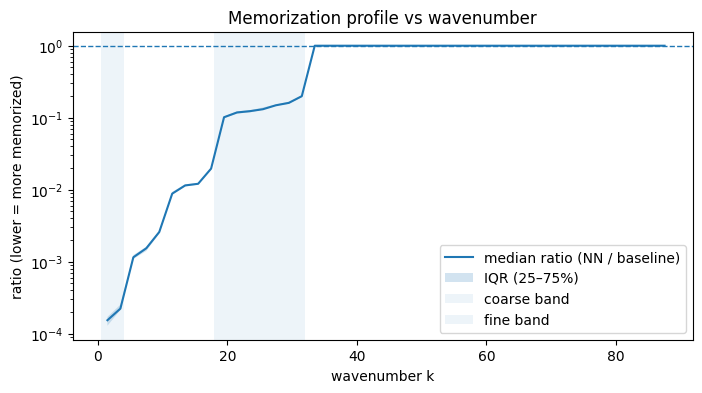

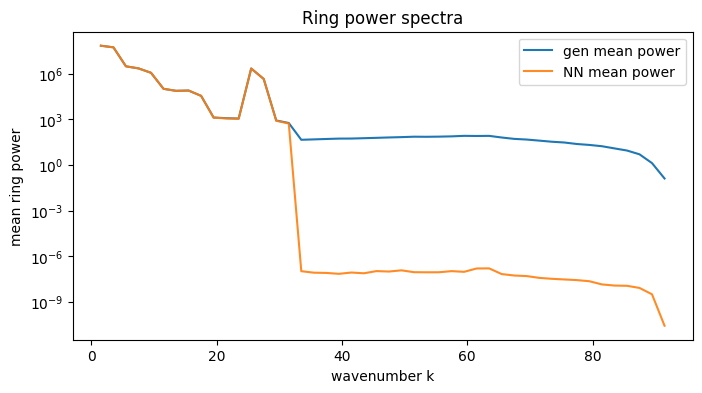

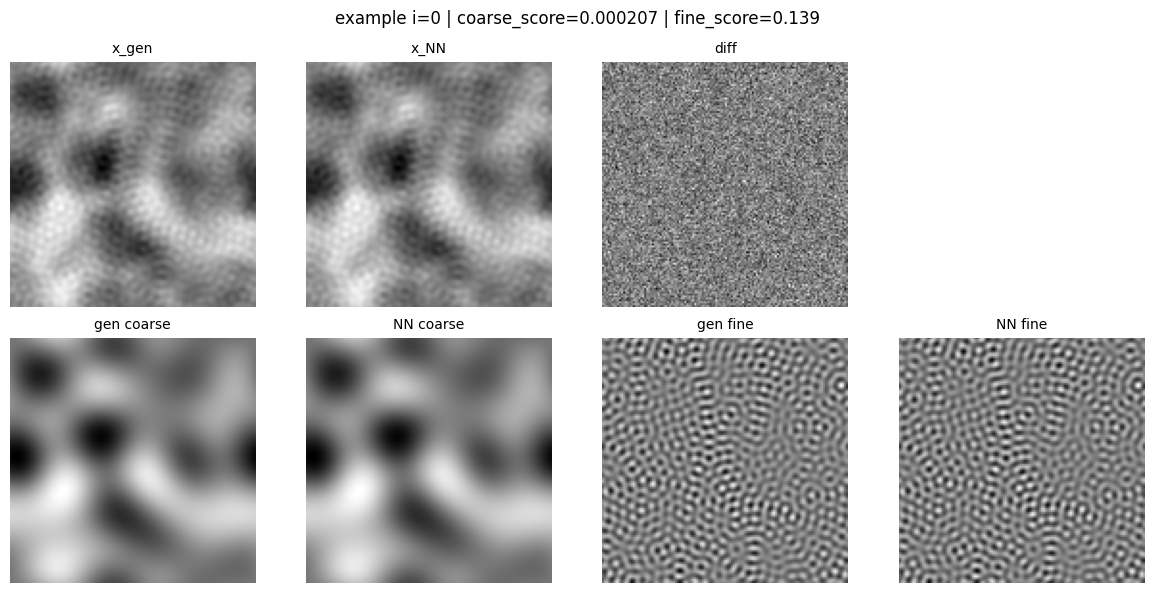

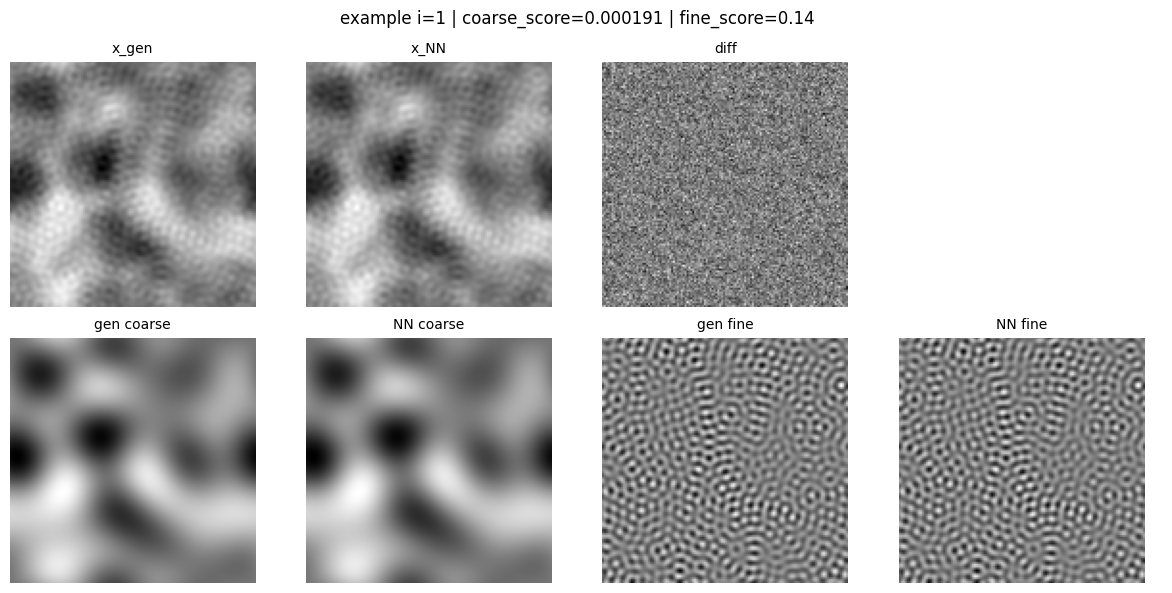

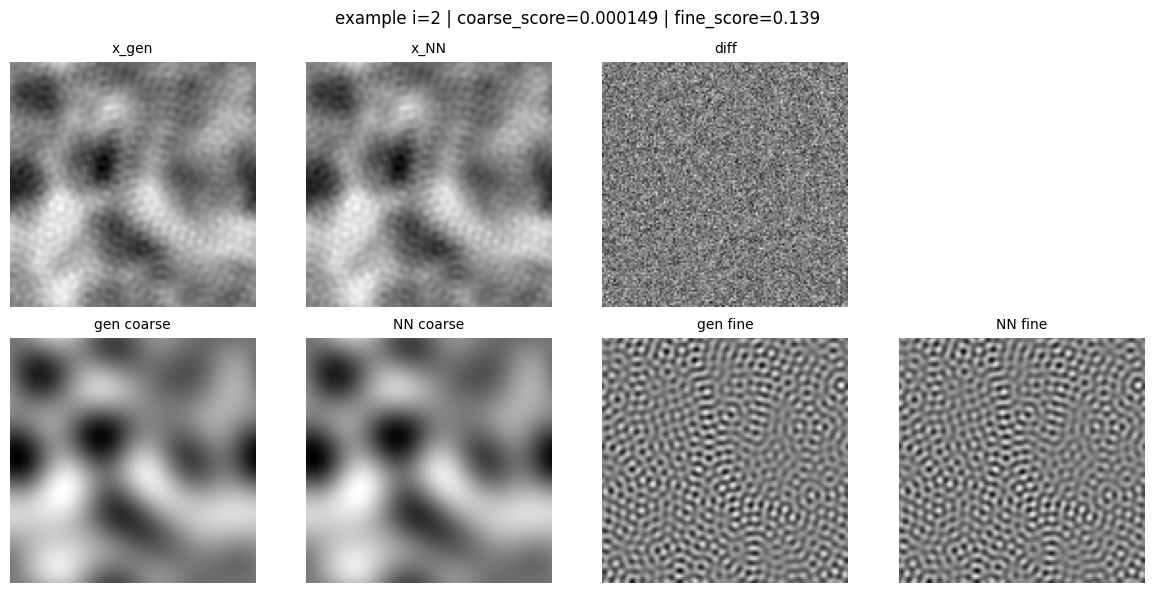

In [19]:
# PLOTTING


kc = k_centers.detach().cpu().numpy()

ratio_cpu = ratio_m.detach().cpu()
med = torch.nanmedian(ratio_cpu, dim=0).values.numpy()
q25 = torch.nanquantile(ratio_cpu, 0.25, dim=0).numpy()
q75 = torch.nanquantile(ratio_cpu, 0.75, dim=0).numpy()

plt.figure(figsize=(8, 4))
plt.plot(kc, med, label="median ratio (NN / baseline)")
plt.fill_between(kc, q25, q75, alpha=0.2, label="IQR (25–75%)")
plt.axhline(1.0, linestyle="--", linewidth=1)
for band_name in ["coarse", "fine"]:
    lo, hi = bands[band_name]
    plt.axvspan(lo, hi, alpha=0.08, label=f"{band_name} band")
plt.yscale("log")
plt.xlabel("wavenumber k")
plt.ylabel("ratio (lower = more memorized)")
plt.title("Memorization profile vs wavenumber")
plt.legend()
plt.show()

pnn = ring_power_rb(xnn, ring_masks, fft_norm=FFT_NORM_RB).detach().cpu()
pg  = p_g.detach().cpu()

plt.figure(figsize=(8, 4))
plt.plot(kc, pg.mean(dim=0).numpy(), label="gen mean power")
plt.plot(kc, pnn.mean(dim=0).numpy(), label="NN mean power", alpha=0.9)
plt.yscale("log")
plt.xlabel("wavenumber k")
plt.ylabel("mean ring power")
plt.title("Ring power spectra")
plt.legend()
plt.show()

cs = coarse_score.detach().cpu().numpy()
fs = fine_score.detach().cpu().numpy()


@torch.no_grad()
def show_examples_rb(idxs, vmax=None):
    for i in idxs:
        xi = xg[i:i+1]
        xni = xnn[i:i+1]
        di = (xi - xni)

        xi_c = band_component_rb(xi, bands["coarse"])
        xni_c = band_component_rb(xni, bands["coarse"])
        xi_f = band_component_rb(xi, bands["fine"])
        xni_f = band_component_rb(xni, bands["fine"])

        fig, axes = plt.subplots(2, 4, figsize=(12, 6))
        items = [
            ("x_gen", xi[0]), ("x_NN", xni[0]), ("diff", di[0]), ("", None),
            ("gen coarse", xi_c[0]), ("NN coarse", xni_c[0]), ("gen fine", xi_f[0]), ("NN fine", xni_f[0]),
        ]
        for ax, (t, img) in zip(axes.flatten(), items):
            ax.axis("off")
            if img is not None:
                ax.imshow(img.detach().cpu().numpy(), cmap="gray", vmin=None, vmax=vmax)
            if t:
                ax.set_title(t, fontsize=10)
        plt.suptitle(f"example i={int(i)} | coarse_score={float(coarse_score[i]):.3g} | fine_score={float(fine_score[i]):.3g}")
        plt.tight_layout()
        plt.show()

cand = torch.nonzero(coarse_mem, as_tuple=False).squeeze(1)
if cand.numel() > 0:
    idxs = cand[: min(3, cand.numel())].detach().cpu().tolist()
    show_examples_rb(idxs)
else:
    print("No coarse-memorized samples under current threshold; try adjusting thresholds or baseline.")
